# Minnesota Road Network — Centrality Analysis

The Minnesota road network is a classic spatial graph benchmark (2,642 nodes, 3,303 edges). Each node is an intersection and each edge is a road segment. We download the adjacency data from the SuiteSparse Matrix Collection and apply centrality measures to identify the most critical intersections.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import pandas as pd
import scipy.io
import urllib.request
import tarfile
import os
import io

## 1. Load the Minnesota Road Network

Download from the SuiteSparse Matrix Collection (Gleich/minnesota) and convert the sparse adjacency matrix to a NetworkX graph. Node coordinates are stored in the `.mtx` auxiliary file.

In [2]:
# Download and extract the Minnesota road network
url = 'https://suitesparse-collection-website.herokuapp.com/MM/Gleich/minnesota.tar.gz'
cache_dir = 'data/minnesota'
mtx_path = os.path.join(cache_dir, 'minnesota', 'minnesota.mtx')

if not os.path.exists(mtx_path):
    os.makedirs(cache_dir, exist_ok=True)
    print('Downloading Minnesota road network...')
    resp = urllib.request.urlopen(url)
    with tarfile.open(fileobj=io.BytesIO(resp.read()), mode='r:gz') as tar:
        tar.extractall(cache_dir)
    print('Done.')

# Load the adjacency matrix
A = scipy.io.mmread(mtx_path)
G_mn = nx.from_scipy_sparse_array(A)
G_mn = nx.Graph(G_mn)  # ensure undirected, remove self-loops
G_mn.remove_edges_from(nx.selfloop_edges(G_mn))

# Keep only the largest connected component
largest_cc = max(nx.connected_components(G_mn), key=len)
G_mn = G_mn.subgraph(largest_cc).copy()

print(f"Nodes: {G_mn.number_of_nodes():,}  Edges: {G_mn.number_of_edges():,}")
print(f"Connected: {nx.is_connected(G_mn)}")

Nodes: 2,640  Edges: 3,302
Connected: True


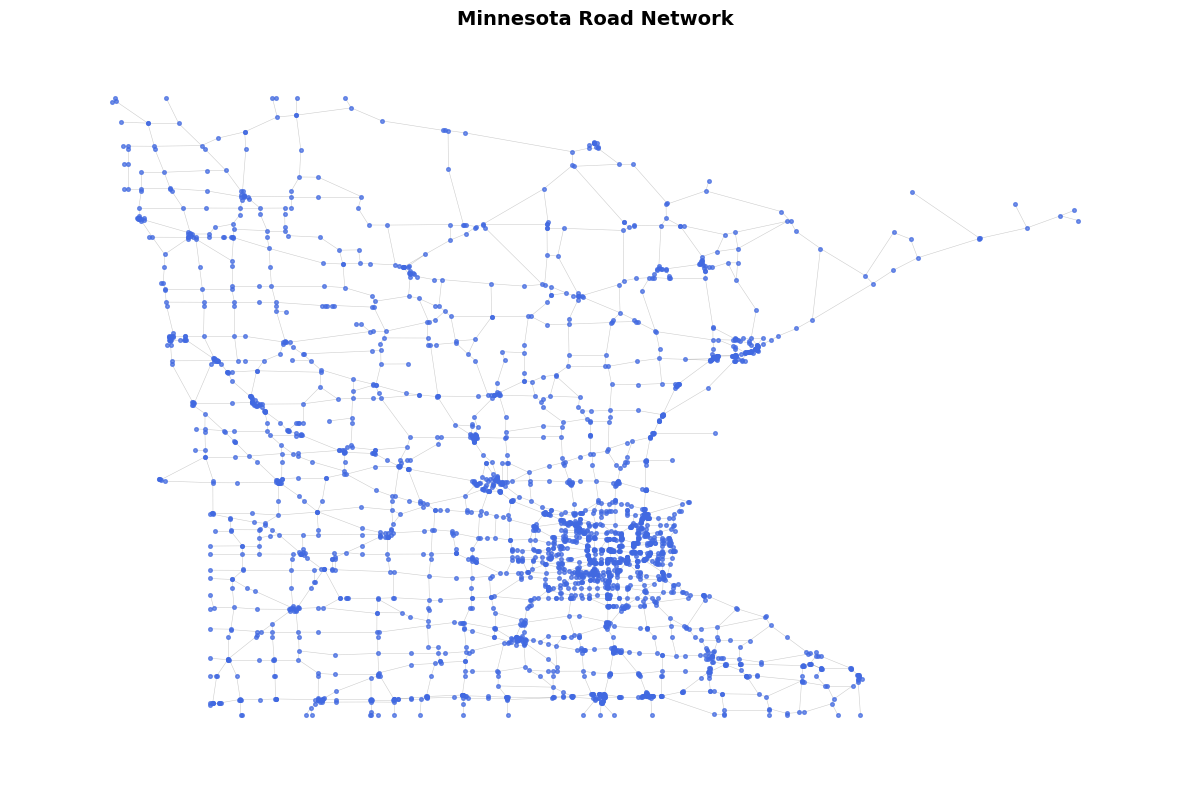

In [3]:
# Try to load coordinates from the auxiliary file, otherwise use spring layout
coord_path = os.path.join(cache_dir, 'minnesota', 'minnesota_coord.mtx')
if os.path.exists(coord_path):
    coords = scipy.io.mmread(coord_path)
    if hasattr(coords, 'toarray'):
        coords = coords.toarray()
    else:
        coords = np.array(coords)
    pos_mn = {i: (coords[i, 0], coords[i, 1]) for i in G_mn.nodes()}
else:
    # Use spectral layout as a reasonable spatial approximation
    pos_mn = nx.spectral_layout(G_mn)

# Quick overview plot
fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(G_mn, pos_mn, ax=ax, alpha=0.2, width=0.4)
nx.draw_networkx_nodes(G_mn, pos_mn, ax=ax, node_size=7, node_color='royalblue', alpha=0.7)
ax.set_title('Minnesota Road Network', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('minnesota_road_network_overview.png', dpi=300, bbox_inches='tight', transparent=True)

## 2. Compute Centrality Measures

We compute degree, closeness, betweenness, eigenvector, and PageRank centralities.

In [4]:
print("Computing centralities (this may take a minute for betweenness)...")

cent_degree      = nx.degree_centrality(G_mn)
cent_closeness   = nx.closeness_centrality(G_mn)
cent_betweenness = nx.betweenness_centrality(G_mn)
cent_eigenvector = nx.eigenvector_centrality(G_mn, max_iter=1000)
cent_pagerank    = nx.pagerank(G_mn)
cent_katz        = nx.katz_centrality(G_mn, alpha=0.1)

centralities_mn = {
    'Degree':      cent_degree,
    'Closeness':   cent_closeness,
    'Betweenness': cent_betweenness,
    'Eigenvector': cent_eigenvector,
    'PageRank':    cent_pagerank,
    'Katz':        cent_katz,
}
print("Done.")

Computing centralities (this may take a minute for betweenness)...


Done.


## 3. Visualise Centralities on the Road Network

Nodes are coloured by centrality score; size is proportional to centrality.

/tmp/ipykernel_28938/2296333800.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(norm(vals_log))


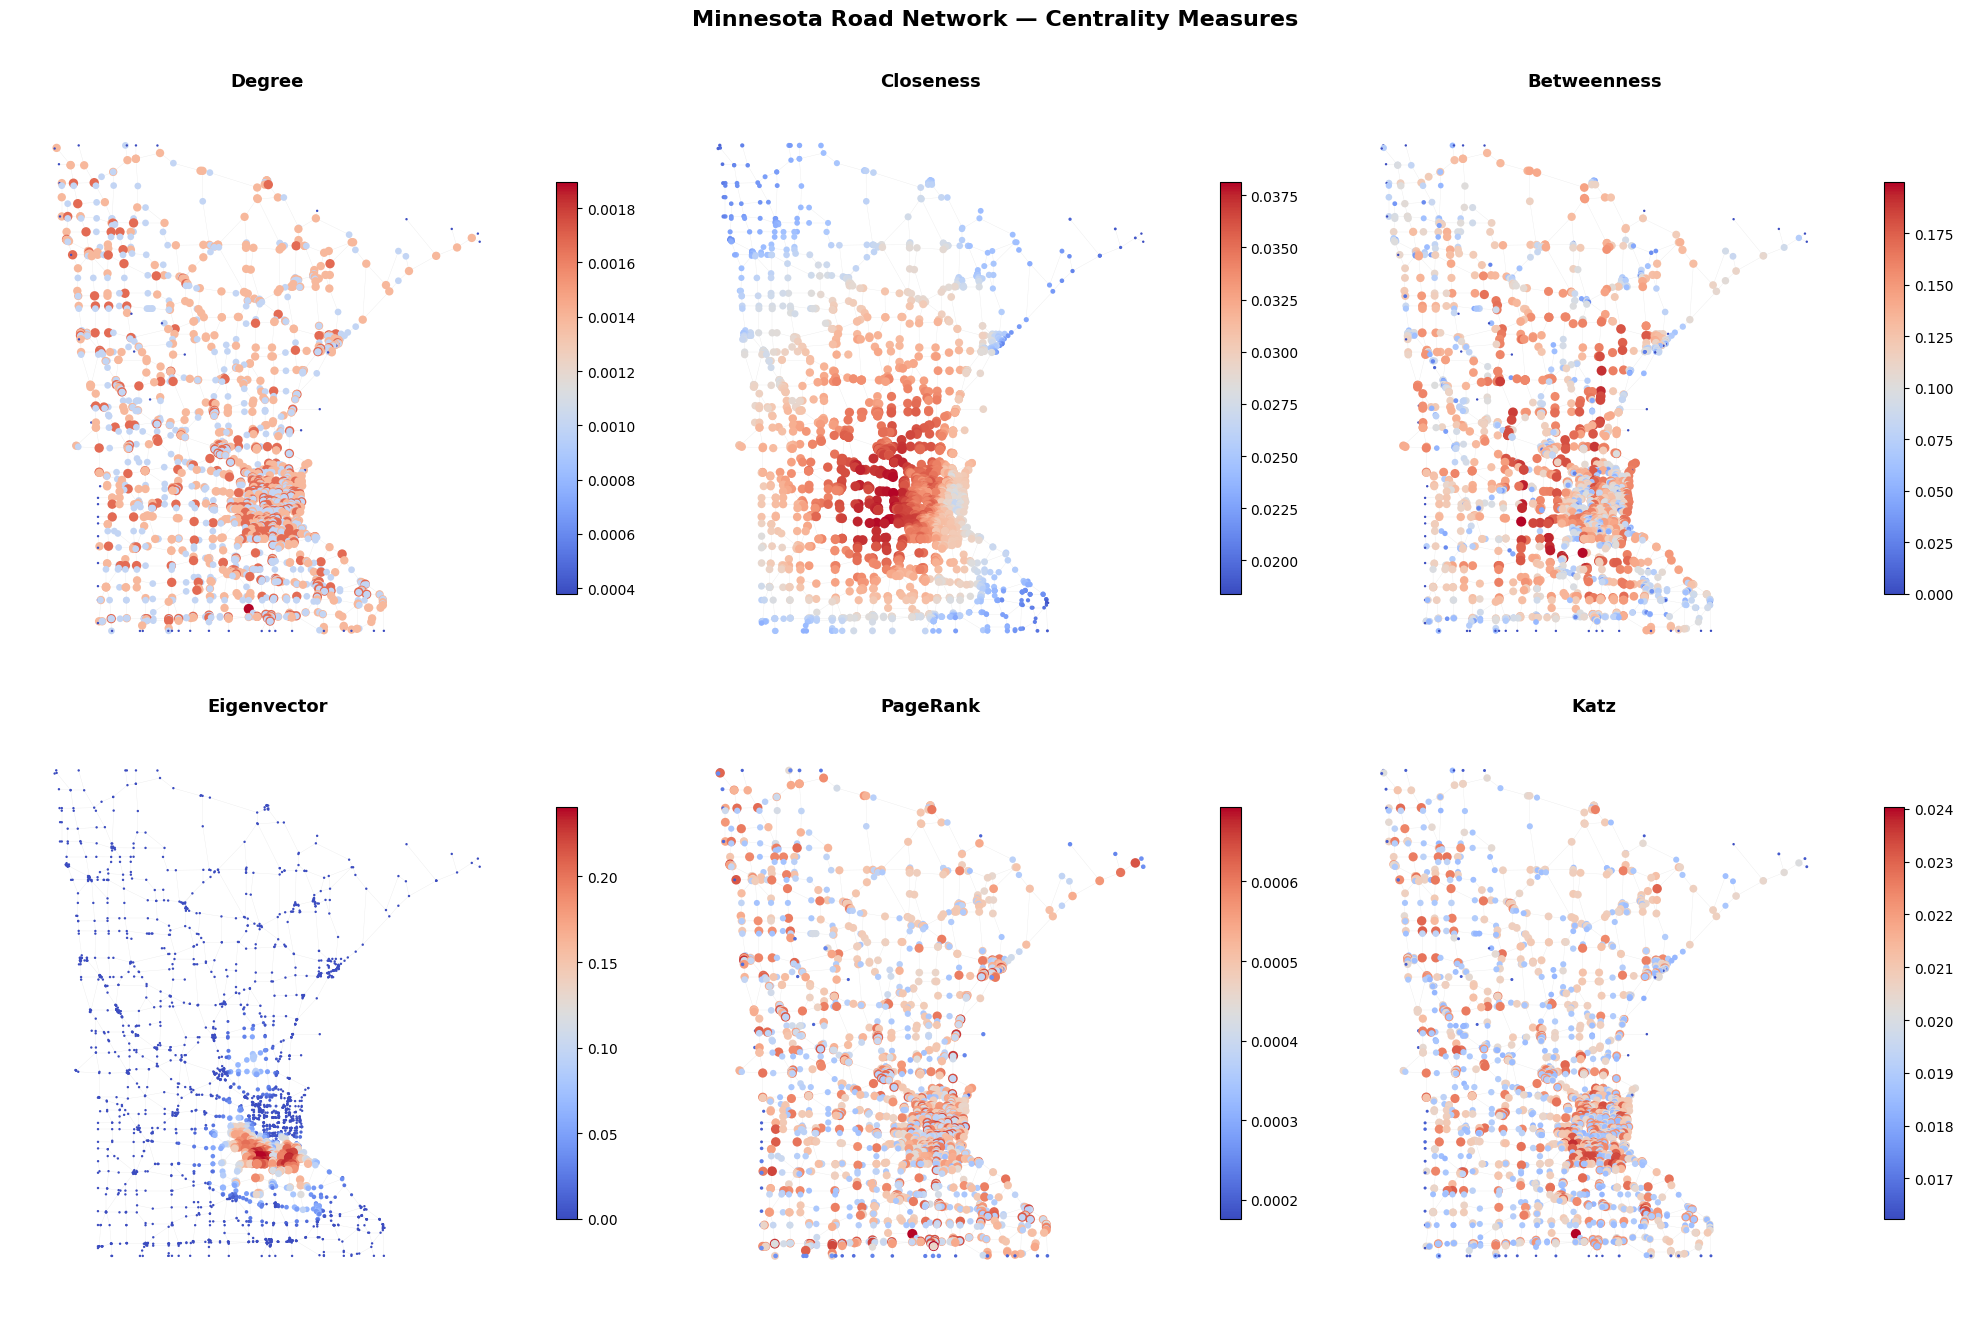

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

for ax, (name, cent) in zip(axes.flat[:6], centralities_mn.items()):
    vals = np.array([cent[n] for n in G_mn.nodes()])
    # Use log scale for better visual contrast (many near-zero values)
    vals_log = np.log1p(vals * 1e4)
    norm = Normalize(vmin=vals_log.min(), vmax=vals_log.max())
    colours = cm.get_cmap('coolwarm')(norm(vals_log))
    sizes = 3 + 50 * norm(vals_log)

    nx.draw_networkx_edges(G_mn, pos_mn, ax=ax, alpha=0.08, width=0.3)
    nx.draw_networkx_nodes(G_mn, pos_mn, ax=ax, node_color=colours,
                           node_size=sizes, edgecolors='none')
    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=vals.min(), vmax=vals.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.7)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.axis('off')

# Hide the unused subplot
axes.flat[5].axis('off')

fig.suptitle('Minnesota Road Network — Centrality Measures', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('minnesota_road_network_centralities.png', dpi=300, bbox_inches='tight', transparent=True)

## 4. Top Intersections by Each Measure

In [6]:
rows = []
for name, cent in centralities_mn.items():
    top10 = sorted(cent, key=cent.get, reverse=True)[:10]
    for rank, node in enumerate(top10, 1):
        rows.append({'Measure': name, 'Rank': rank, 'Node': node, 'Score': cent[node]})

df_top = pd.DataFrame(rows)
df_top.pivot(index='Rank', columns='Measure', values='Node')

Measure,Betweenness,Closeness,Degree,Eigenvector,Katz,PageRank
Rank,,,,,,
1,1820,1355,2417,1911,2417,2417
2,2068,1819,31,1918,1787,2596
3,2062,1108,34,1947,1926,384
4,1536,1837,38,1926,1986,2561
5,1215,1354,54,1949,1777,803
6,1963,1570,62,1916,1918,1447
7,2078,1781,80,1945,1947,701
8,1962,1583,82,1929,1916,649
9,1589,1784,89,1883,1932,2533


## 5. Centrality Correlation Heatmap

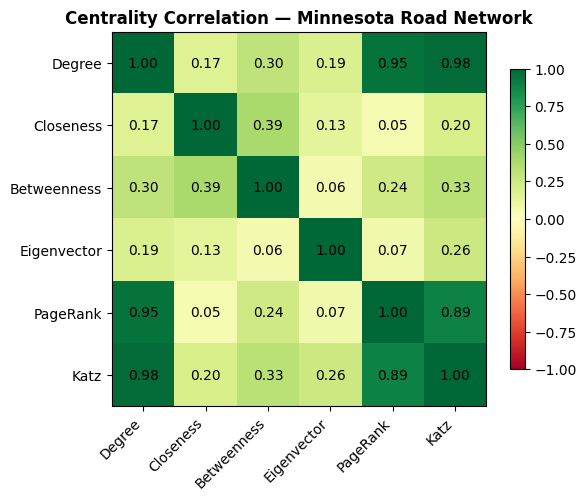

In [7]:
df_cent_mn = pd.DataFrame(centralities_mn)
corr = df_cent_mn.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Centrality Correlation — Minnesota Road Network', fontweight='bold')
plt.tight_layout()
plt.savefig('minnesota_road_network_centralities_corr.png', dpi = 300, bbox_inches='tight', transparent=True)

## 6. Centrality Distributions

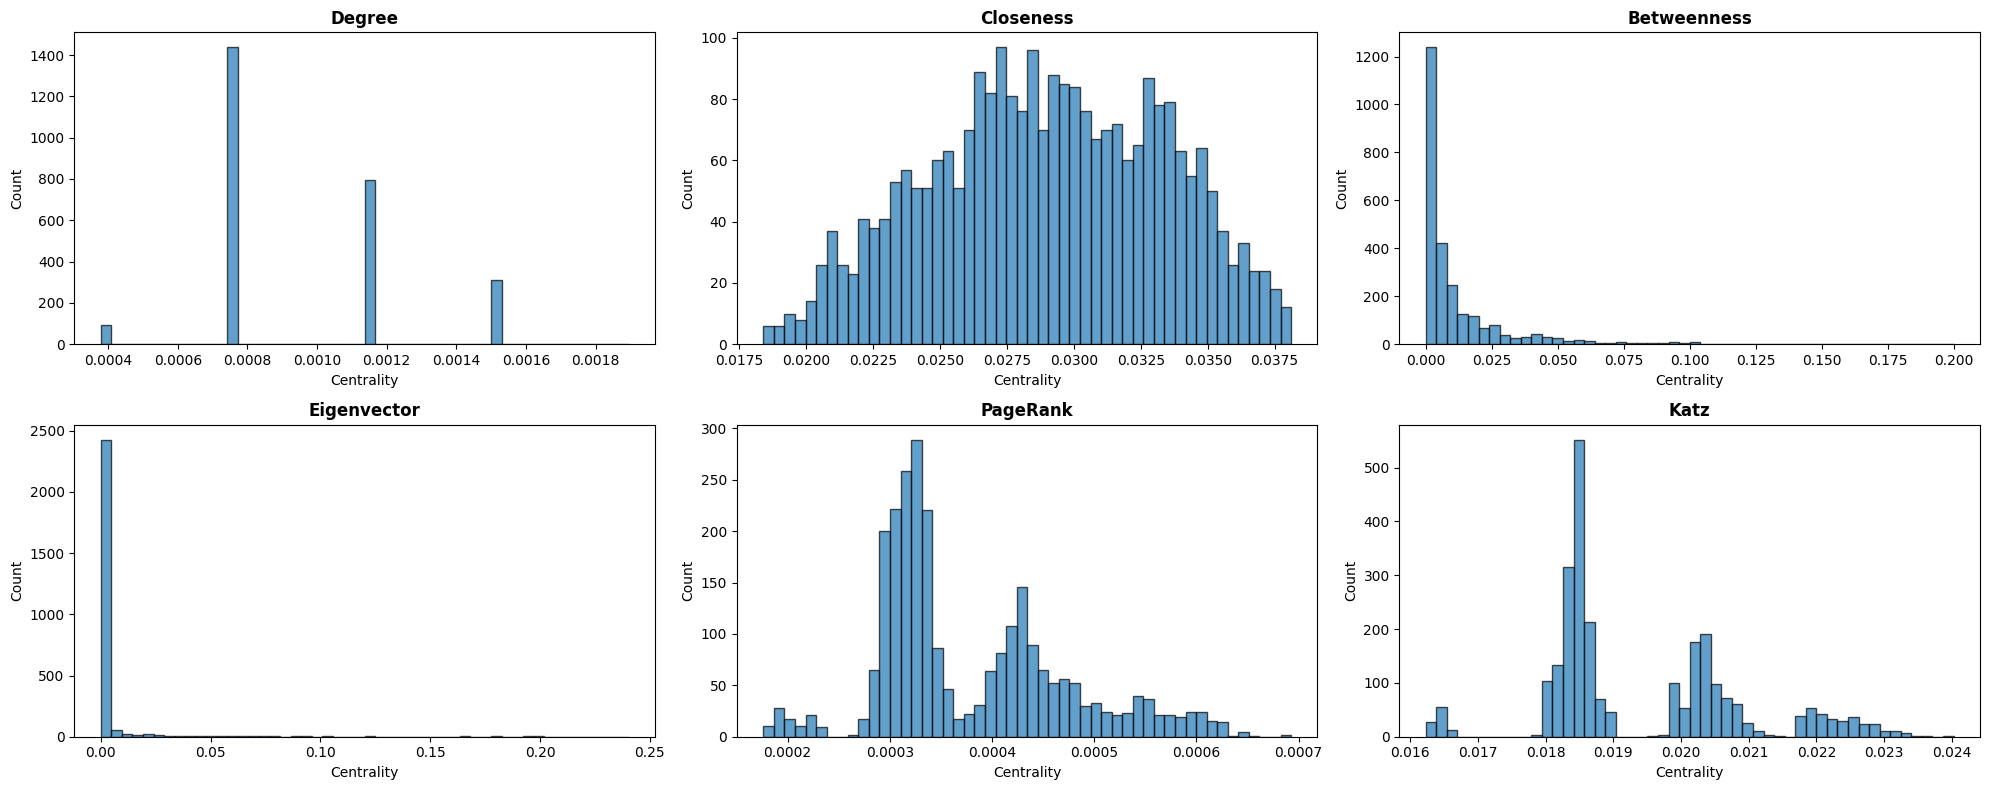

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for ax, (name, cent) in zip(axes.flat, centralities_mn.items()):
    vals = list(cent.values())
    ax.hist(vals, bins=50, edgecolor='k', alpha=0.7)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Centrality')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('centrality_distributions.png', dpi=300, bbox_inches='tight', transparent=True)

## 7. Top 10 Nodes Highlighted on the Road Network

Visualise the top-10 highest-centrality nodes for each measure, overlaid on the road network map with distinct colours.

/tmp/ipykernel_28938/2333264875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('Reds')(norm(vals_top))


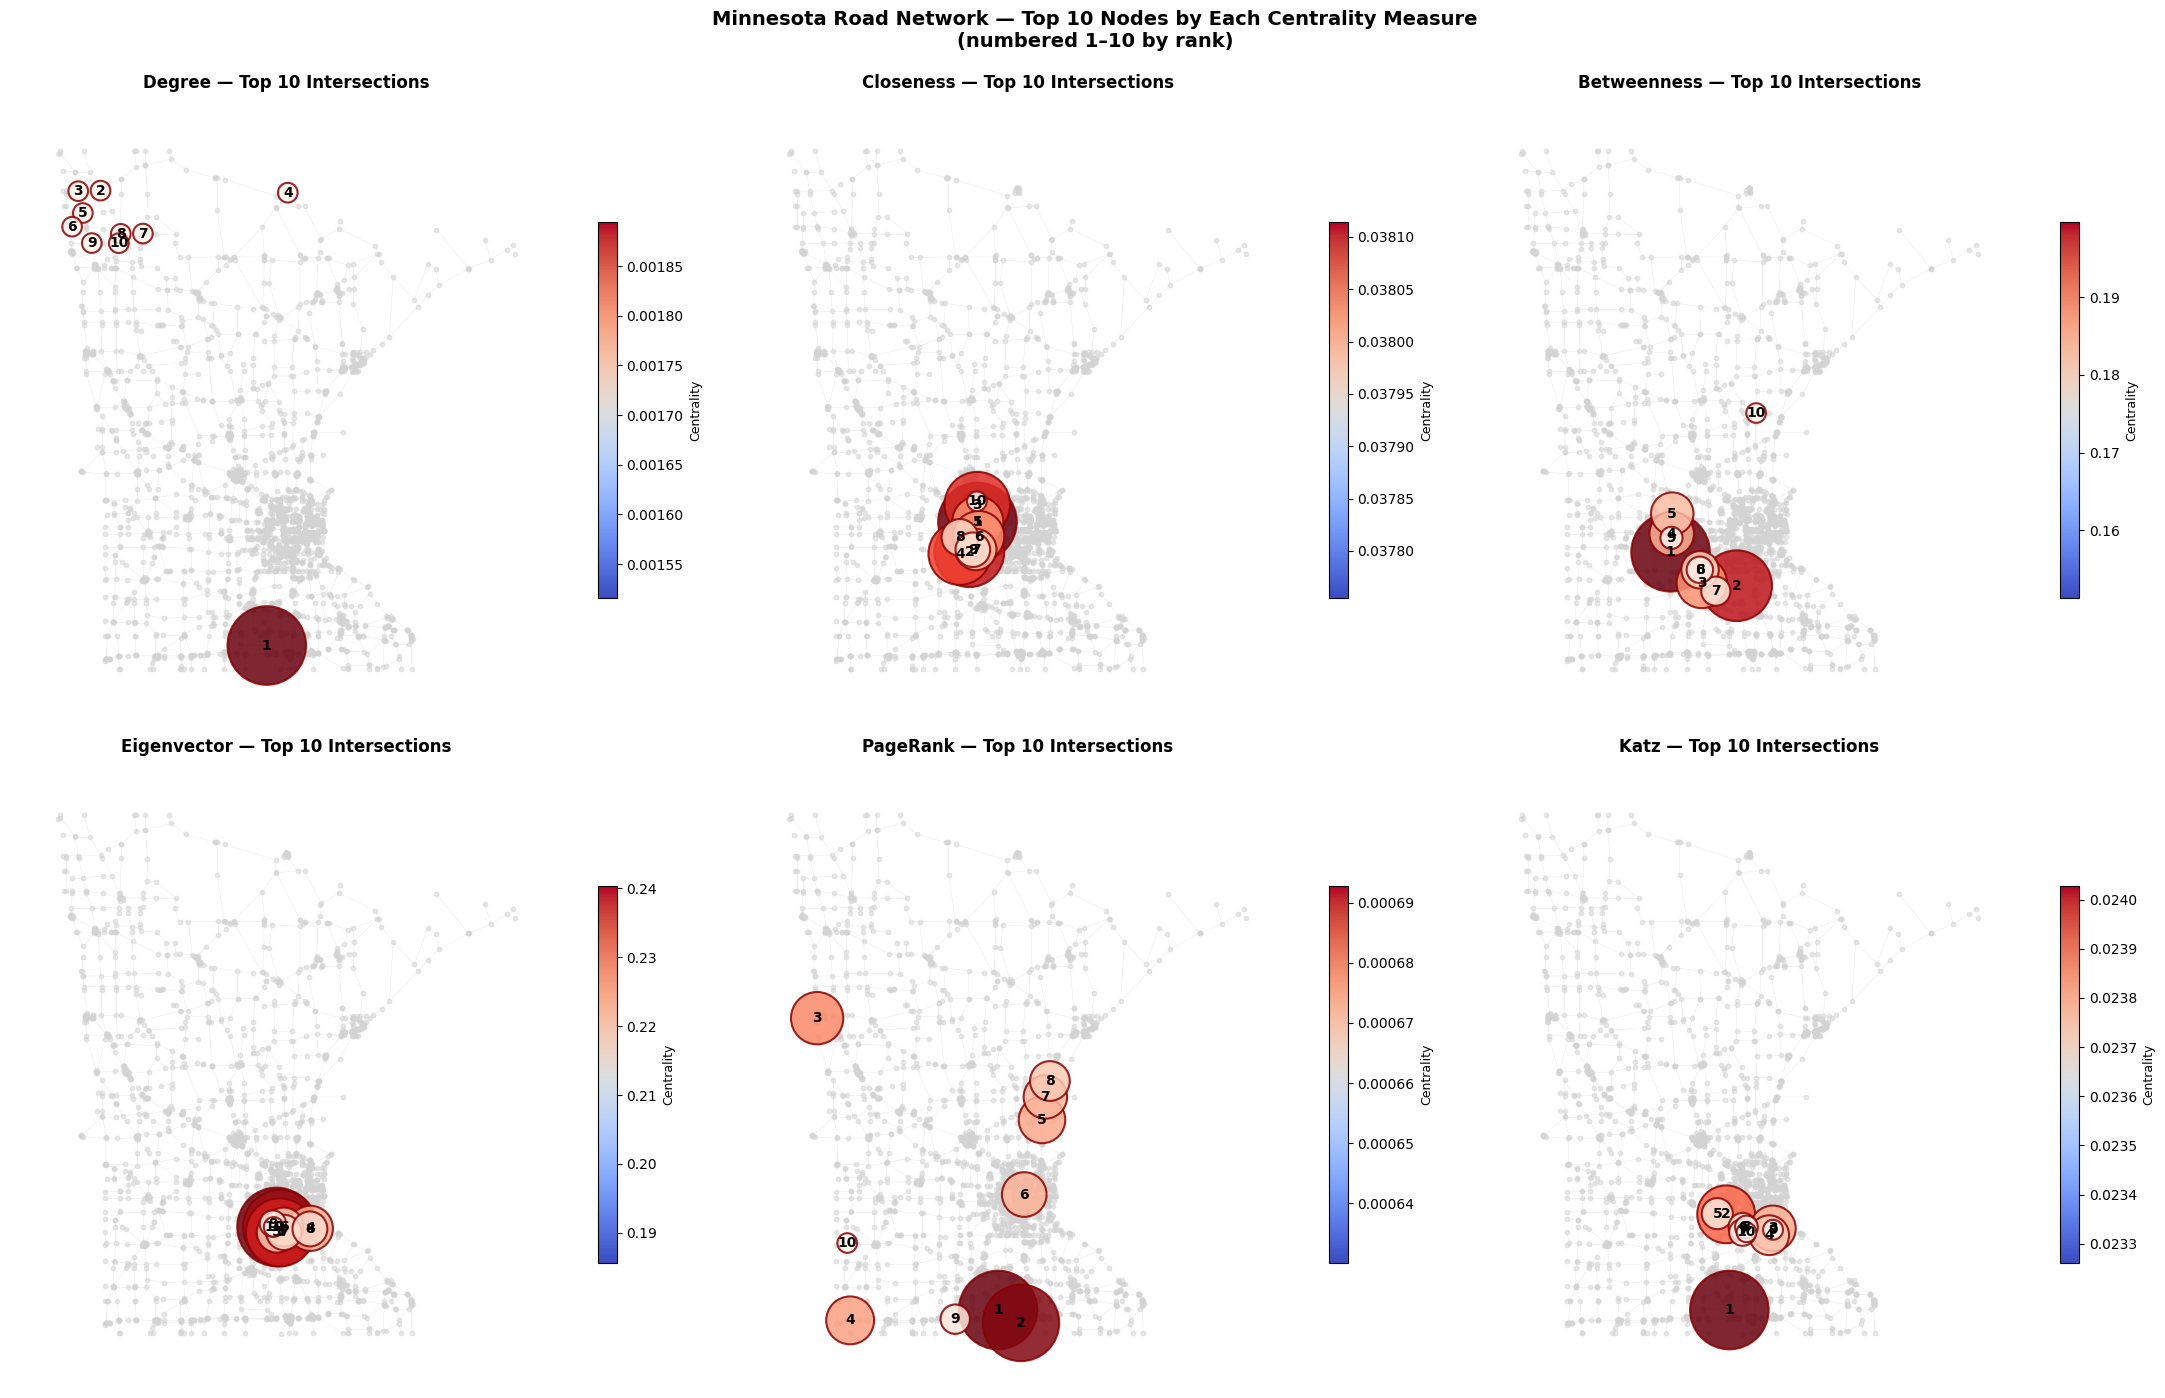

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for ax, (name, cent) in zip(axes.flat, centralities_mn.items()):
    # Get top 10 nodes
    top10_nodes = sorted(cent, key=cent.get, reverse=True)[:10]
    top10_set = set(top10_nodes)
    
    # Draw all edges in light grey
    nx.draw_networkx_edges(G_mn, pos_mn, ax=ax, alpha=0.15, width=0.4, edge_color='grey')
    
    # Draw all nodes in light blue (background)
    all_nodes = list(G_mn.nodes())
    background_nodes = [n for n in all_nodes if n not in top10_set]
    nx.draw_networkx_nodes(G_mn, pos_mn, nodelist=background_nodes, ax=ax,
                           node_size=10, node_color='lightgrey', alpha=0.5)
    
    # Draw top 10 nodes with colour gradient and sizes proportional to centrality
    vals_top = np.array([cent[n] for n in top10_nodes])
    norm = Normalize(vmin=vals_top.min(), vmax=vals_top.max())
    colours = cm.get_cmap('Reds')(norm(vals_top))
    sizes = 200 + 3000 * norm(vals_top)
    
    nx.draw_networkx_nodes(G_mn, pos_mn, nodelist=top10_nodes, ax=ax,
                           node_color=colours, node_size=sizes, edgecolors='darkred',
                           linewidths=1.5, alpha=0.85)
    
    # Add labels for top 10
    labels_top = {n: str(list(top10_nodes).index(n) + 1) for n in top10_nodes}
    nx.draw_networkx_labels(G_mn, pos_mn, labels=labels_top, ax=ax, font_size=10, font_weight='bold')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
    cbar.set_label('Centrality', fontsize=9)
    
    ax.set_title(f'{name} — Top 10 Intersections', fontsize=12, fontweight='bold')
    ax.axis('off')

fig.suptitle('Minnesota Road Network — Top 10 Nodes by Each Centrality Measure\n(numbered 1–10 by rank)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('minnesota_road_network_top10.png', dpi=300, bbox_inches='tight', transparent=True)